## Moirai 2 Embedding Alma 

In [66]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
from einops import rearrange
from gluonts.dataset.multivariate_grouper import MultivariateGrouper
from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split

from uni2ts.eval_util.plot import plot_single, plot_next_multi
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule
from uni2ts.model.moirai_moe import MoiraiMoEForecast, MoiraiMoEModule
from uni2ts.model.moirai2 import Moirai2Forecast, Moirai2Module


In [67]:
DATA_PATH = "data/commodity_prices.csv"

module= Moirai2Module.from_pretrained(
    "Salesforce/moirai-2.0-R-small"
)

In [68]:
module

Moirai2Module(
  (scaler): PackedStdScaler()
  (in_proj): ResidualBlock(
    (hidden_layer): Linear(in_features=32, out_features=384, bias=True)
    (silu): SiLU()
    (output_layer): Linear(in_features=384, out_features=384, bias=True)
    (residual_layer): Linear(in_features=32, out_features=384, bias=True)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): GroupedQueryAttention(
          (var_attn_bias): BinaryAttentionBias(
            (emb): Embedding(2, 6)
          )
          (time_qk_proj): QueryKeyProjection(
            (query_proj): RotaryProjection()
            (key_proj): RotaryProjection()
          )
          (q_proj): Linear(in_features=384, out_features=384, bias=False)
          (k_proj): Linear(in_features=384, out_features=384, bias=False)
          (v_proj): Linear(in_features=384, out_features=384, bias=False)
          (q_norm): RMSNorm(normalized_shape=(64,), eps=1e-05, weight=True)
 

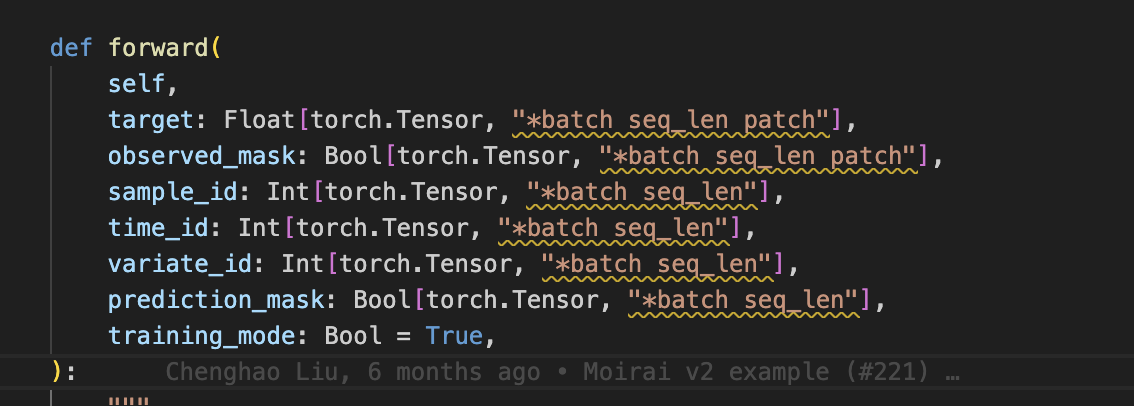

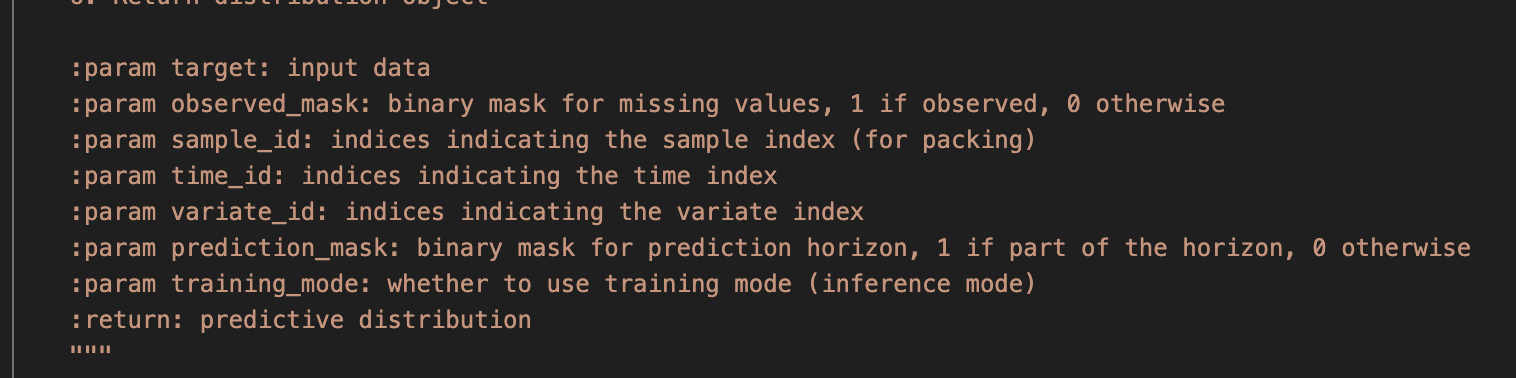

In [69]:
df = pd.read_csv(DATA_PATH)
df

,date,BZ=F,CL=F,GC=F,HG=F,HO=F,NG=F,PA=F,PL=F,SI=F,ZC=F
0,2010-01-04,80.120003,81.510002,1117.699951,3.3880,2.1905,5.884,419.799988,1517.300049,17.440001,418.50
1,2010-01-05,80.589996,81.769997,1118.099976,3.3960,2.1941,5.637,420.350006,1530.800049,17.781000,418.75
2,2010-01-06,81.889999,83.180000,1135.900024,3.4775,2.2032,6.009,425.600006,1552.199951,18.163000,421.75
3,2010-01-07,81.510002,82.660004,1133.099976,3.4115,2.1836,5.806,422.950012,1553.000000,18.333000,417.50
4,2010-01-08,81.370003,82.750000,1138.199951,3.3880,2.2003,5.749,424.149994,1564.599976,18.458000,423.00
...,...,...,...,...,...,...,...,...,...,...,...
3768,2024-12-24,73.580002,70.099998,2620.000000,4.0495,2.2215,3.946,938.299988,958.500000,29.974001,448.50
3769,2024-12-26,73.260002,69.620003,2638.800049,4.0720,2.2053,3.715,906.400024,952.200012,30.047001,453.75
3770,2024-12-27,74.169998,70.599998,2617.199951,4.0625,2.2448,3.514,893.599976,917.500000,29.655001,454.00
3771,2024-12-30,74.389999,70.989998,2606.100098,4.0455,2.2995,3.936,894.200012,902.400024,29.106001,452.25


In [70]:
df = df["BZ=F"]

In [71]:
batch_size = 1
context_length = 512
patch_len = 16
seq_len = context_length // 16


In [72]:
values = df.values[-context_length:]

In [73]:
values_tensor = torch.tensor(values, dtype= torch.float32)

### Value'ları tensor'e çevir ve uygun shape'e sok 

In [74]:
batch_size= 1 
context_length = 512 
patch_len = 16
seq_len = context_length // 16

values_tensor = values_tensor.view(batch_size, seq_len, patch_len)

### Is observed 

In [75]:
is_observed = ~torch.isnan(values_tensor)
is_observed.shape

torch.Size([1, 32, 16])

## Sample Id

In [76]:
sample_id = torch.zeros((batch_size, seq_len), dtype= torch.int32)
sample_id.shape

torch.Size([1, 32])

### Time Id

In [77]:
time_index = torch.arange(0, seq_len, dtype= torch.int32).unsqueeze(0)
time_index.shape


torch.Size([1, 32])

In [78]:
variate_id = torch.zeros((batch_size, seq_len), dtype= torch.int32)
variate_id.shape

torch.Size([1, 32])

## Prediction Mask

In [79]:
pred_mask = torch.zeros((batch_size, seq_len), dtype= torch.int32)
pred_mask.shape

torch.Size([1, 32])

In [80]:
trainin_mode= False

In [81]:
with torch.no_grad():
    embeddings = module.forward(
        target=values_tensor,
        observed_mask=is_observed,
        sample_id=sample_id,
        time_id=time_index,
        variate_id=variate_id,
        prediction_mask=pred_mask,
        training_mode=False,
    )

In [83]:
embeddings.shape

torch.Size([1, 32, 384])

In [84]:
32*384

12288